In [1]:
#imports
import matplotlib.pyplot as plt
import numpy as np
import uproot
import pandas as pd

In [2]:
#open root file
#df = uproot.open(
 #   "/volatile/clas12/cooperb/SULI/pid_training_test.root:PhysicsEvents"
#).arrays(library="pd")
cols = ["pid", "mc_matching_pid", "p", "theta", "beta", "chi2pid", "rich_RQ", "vz"]
df = uproot.open("/volatile/clas12/cooperb/SULI/pid_training_v1.root:PhysicsEvents").arrays(cols, library="pd")

In [3]:
#creates a list of matching events (excludes events that failed matching)
matched = df[df["mc_matching_pid"] != -9999].copy()
direct = "/work/clas12/CooperBe/Argonne2026/suli2026_pid/figures/BetaVsP/"

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
for pid_val, label, color in [(211, "pi+", "blue"),
                               (321, "K+",  "green"),
                               (2212, "p",   "red")]:
    subset = matched[matched["mc_matching_pid"] == pid_val] #ask about what this line does
    ax.hist2d(subset["p"], subset["beta"],
              bins=[50, 50], range=[[0.5, 5.0], [0.6, 1.1]],
              alpha=0.6, label=label, cmap="Blues" if pid_val==211 else
                                          "Greens" if pid_val==321 else "Reds")
ax.set_xlabel("p (GeV/c)")
ax.set_ylabel("beta")
ax.set_title("beta vs p by MC truth class")
fig.tight_layout()
fig.savefig(direct+ "beta_vs_p_truth_classes.png", dpi=150)
plt.close(fig)

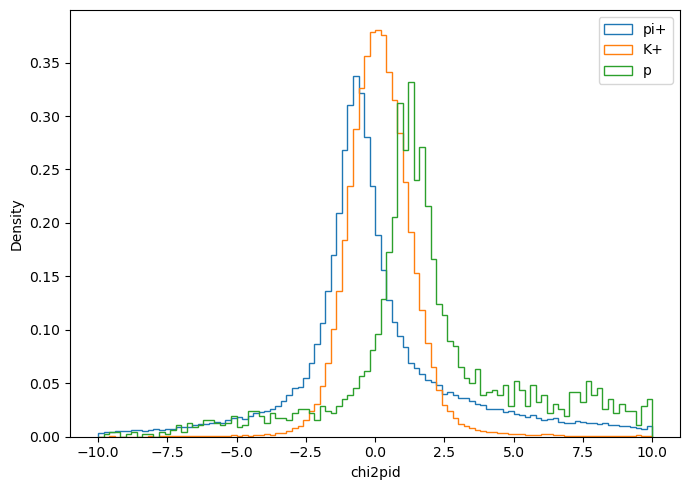

In [10]:
fig, ax2 = plt.subplots(figsize=(7, 5))

subset = matched[matched["pid"] == 321]

for pid_val, label in [(211, "pi+"), (321, "K+"), (2212, "p")]:
    subset2 = subset[subset["mc_matching_pid"] == pid_val]

    ax2.hist(
        subset2["chi2pid"],
        bins=100,
        range=(-10, 10),          # <-- key fix (prevents edge artifacts)
        histtype="step",
        density=True,
        label=label
    )

ax2.set_xlabel("chi2pid")
ax2.set_ylabel("Density")
ax2.legend()

fig.tight_layout()
fig.savefig(direct + "chi2pid_by_truth_classV2.png", dpi=150)

plt.show()
plt.close(fig)

In [6]:
fig, ax2 = plt.subplots(figsize=(7, 5))
for pid_val, label in [(211, "pi+"), (321, "K+"), (2212, "p")]:
    subset = matched[matched["mc_matching_pid"] == pid_val]
    ax2.hist(subset["chi2pid"].clip(-10, 10), bins=100, histtype="step",
            label=label, density=True)
ax2.set_xlabel("chi2pid"); ax2.set_ylabel("Density"); ax2.legend()
fig.tight_layout()
fig.savefig(direct +"chi2pid_by_truth_class.png", dpi=150)
plt.close(fig)

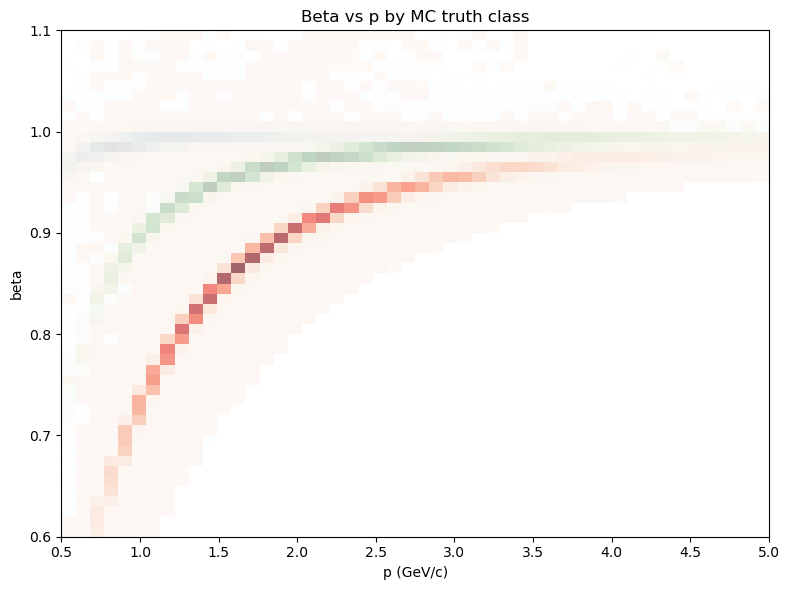

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

for pid_val, label, cmap_name in [
    (211, "pi+", "Blues"),
    (321, "K+", "Greens"),
    (2212, "p", "Reds")
]:
    subset = matched[matched["mc_matching_pid"] == pid_val]
    #subset = subset[subset["pid"] == 321]

    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_under("white")

    ax.hist2d(
        subset["p"],
        subset["beta"],
        bins=[50, 50],
        range=[[0.5, 5.0], [0.6, 1.1]],
        cmap=cmap,
        vmin=1,      # anything below 1 count becomes white
        alpha=0.6
    )

ax.set_facecolor("white")

ax.set_xlabel("p (GeV/c)")
ax.set_ylabel("beta")
ax.set_title("Beta vs p by MC truth class")

fig.tight_layout()
fig.savefig(direct + "beta_vs_p_truth_classes.png", dpi=150)

plt.show()
plt.close(fig)